In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# 🫀 Dataset Description

## Context

Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worldwide. Four out of 5CVD deaths are due to heart attacks and strokes, and one-third of these deaths occur prematurely in people under 70 years of age. Heart failure is a common event caused by CVDs and this dataset contains 11 features that can be used to predict a possible heart disease.

People with cardiovascular disease or who are at high cardiovascular risk (due to the presence of one or more risk factors such as hypertension, diabetes, hyperlipidaemia or already established disease) need early detection and management wherein a machine learning model can be of great help.



## Source

This dataset was created by combining different datasets already available independently but not combined before. In this dataset, 5 heart datasets are combined over 11 common features which makes it the largest heart disease dataset available so far for research purposes. The five datasets used for its curation are:

Cleveland: 303 observations
Hungarian: 294 observations
Switzerland: 123 observations
Long Beach VA: 200 observations
Stalog (Heart) Data Set: 270 observations
Total: 1190 observations
Duplicated: 272 observations

Final dataset: 918 observations

Every dataset used can be found under the Index of heart disease datasets from UCI Machine Learning Repository on the following link: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/

Citation
fedesoriano. (September 2021). Heart Failure Prediction Dataset. Retrieved [Date Retrieved] from https://www.kaggle.com/fedesoriano/heart-failure-prediction.

# Acknowledgements:

Creators:

Hungarian Institute of Cardiology. Budapest: Andras Janosi, M.D.
University Hospital, Zurich, Switzerland: William Steinbrunn, M.D.
University Hospital, Basel, Switzerland: Matthias Pfisterer, M.D.
V.A. Medical Center, Long Beach and Cleveland Clinic Foundation: Robert Detrano, M.D., Ph.D.
Donor:
David W. Aha (aha '@' ics.uci.edu) (714) 856-8779

In [ ]:
#reading the dataset into dataframe for analysis
url = "https://raw.githubusercontent.com/anoushka-j/heart_failure_data/refs/heads/main/heart.csv"

heart_data_csv = pd.read_csv(url)

#printing dataset metadata
print(heart_data_csv)
print(heart_data_csv.shape)
print(heart_data_csv.dtypes)

     Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA        140          289          0     Normal   
1     49   F           NAP        160          180          0     Normal   
2     37   M           ATA        130          283          0         ST   
3     48   F           ASY        138          214          0     Normal   
4     54   M           NAP        150          195          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA        110          264          0     Normal   
914   68   M           ASY        144          193          1     Normal   
915   57   M           ASY        130          131          0     Normal   
916   57   F           ATA        130          236          0        LVH   
917   38   M           NAP        138          175          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0      172              N  

# 🫀 Domain knowledge and Feature Descriptions

 The dataset contains the following features, often collected by medical professionals to analyze patient's conditions as they relate to heart disease. The following table contains the descriptions of all features found in the dataset.

| **Feature**        | **Description**                                                                                                          | **Type**                             |
|--------------------|--------------------------------------------------------------------------------------------------------------------------|--------------------------------------|
| **Age**            | Age of the patient [years]                                                                                                | Numerical                            |
| **Sex**            | Sex of the patient [M: Male, F: Female]                                                                                   | Categorical (binary)                |
| **ChestPainType**  | Chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]                      | Categorical (nominal)               |
| **RestingBP**      | Resting blood pressure [mm Hg]                                                                                             | Numerical                            |
| **Cholesterol**    | Serum cholesterol [mm/dl]                                                                                                 | Numerical                            |
| **FastingBS**      | Fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]                                                           | Categorical (binary)                |
| **RestingECG**     | Resting electrocardiogram results [Normal: Normal, ST: ST-T wave abnormality, LVH: Left ventricular hypertrophy]          | Categorical (nominal)               |
| **MaxHR**          | Maximum heart rate achieved [Numeric value between 60 and 202]                                                           | Numerical                            |
| **ExerciseAngina** | Exercise-induced angina [Y: Yes, N: No]                                                                                   | Categorical (binary)                |
| **Oldpeak**        | Oldpeak = ST depression [Numeric value measured in depression]                                                            | Numerical                            |
| **ST_Slope**       | Slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]                                      | Categorical (nominal)               |
| **HeartDisease**   | Output class [1: heart disease, 0: Normal]                                                                                | Categorical (binary)                |



# 🫀 Analysis of Heart Failure Data

The following ten insights represent what information can be gathered through exploratory analysis of the data.

## 🫀 Age Distribution

### (r1) Simple histogram for visualization of dispersion

#### 1) Insight: The age group most commonly represented among the patients (whether they had heart disease or not) was between 50 and 60 years old.




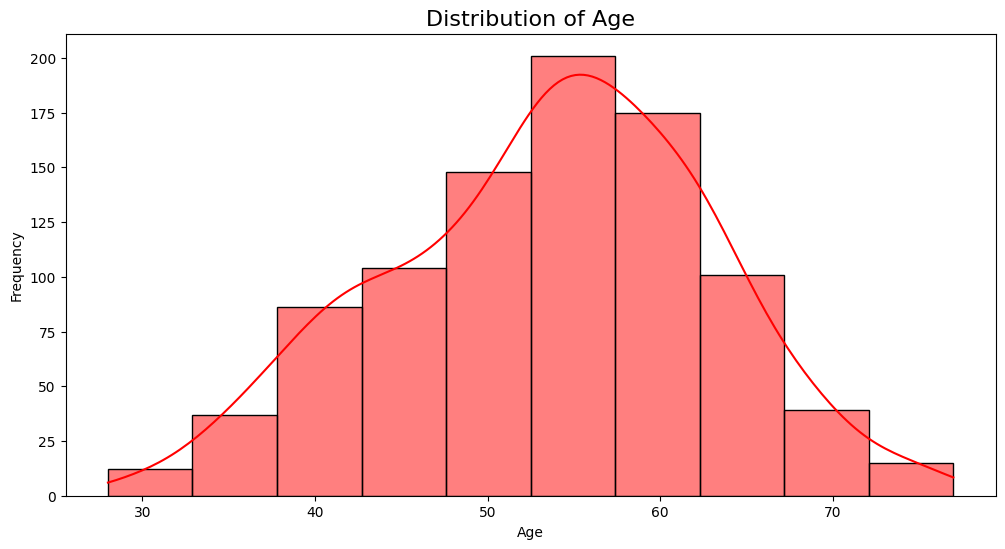

In [ ]:
#sizing figure
plt.figure(figsize=(12, 6))
#creating histogram with 10 "bins" aka categories of age, and adding kernel density estimation line to follow histogram bars
sns.histplot(heart_data_csv['Age'], bins=10, kde=True, color='red')

#titles and labels
plt.title('Distribution of Age', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

## 🫀 Counts of Different Types of Chest Pain

### (r2) Countplot for a category with multiple values

#### 2) Insight: The most prevalent type of chest pain among the patients in dataset is atypical chest pain.

<ipython-input-7-7d8ff1f3f625>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='ChestPainType', data=heart_data_csv, palette='Reds')


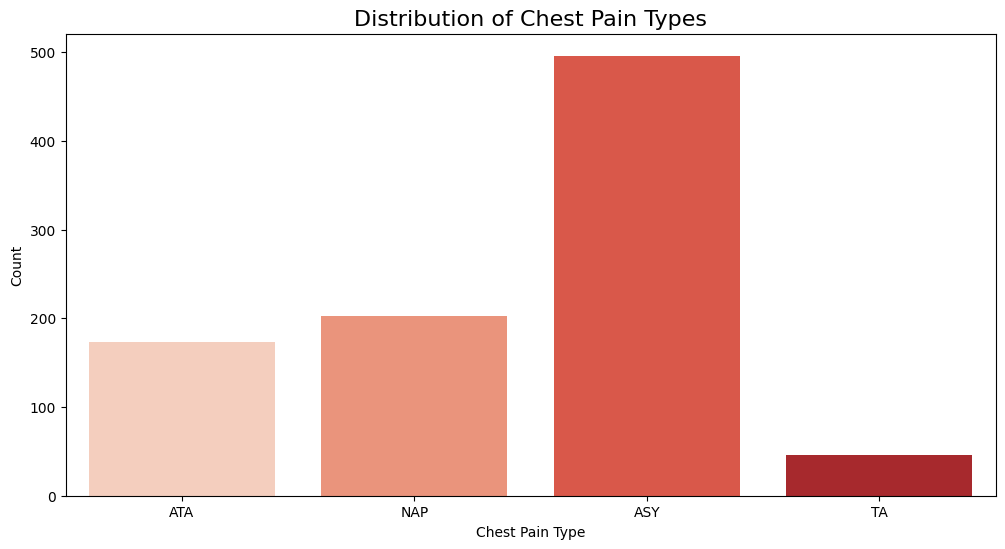

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ChestPainType', data=heart_data_csv, palette='Reds')
plt.title('Distribution of Chest Pain Types', fontsize=16)
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

## 🫀 Grouping Counts of Different Types of Chest Pain by Gender

### (r3) Grouped-Data countplot in which you group some values

The data was grouped by type of chest pain and gender, as seen below:

#### 3) Insight: Overall male patients were more represented in the types of chest pain, with greatest discrepancy between male and female patients occuring with atypical chest pain.

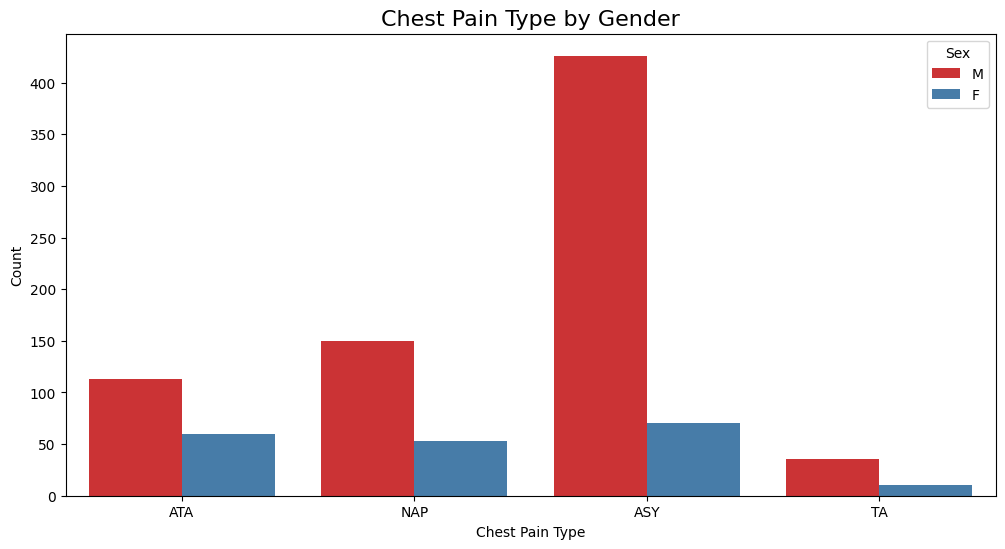

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ChestPainType', hue='Sex', data=heart_data_csv, palette='Set1')
plt.title('Chest Pain Type by Gender', fontsize=16)
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

## 🫀 Heart Disease Prevalence by Gender

### (r4) Comparing categories with 2 values

The categories compared were gender (Male/Female) and heart disease (0 or 1 depending on whether the patient was diagnosed). Each of these categorical features have two values.

#### 4) Insight: While male patients are represented more in the dataset, they also have higher proportinality/chance of having heart disease compared to female patients. So, heart disease is found far more often in male patients.

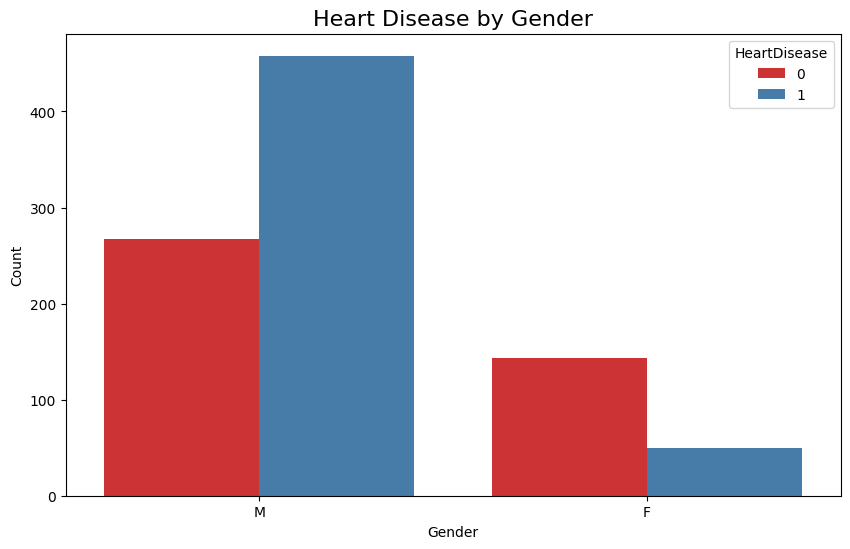

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Sex', hue='HeartDisease', data=heart_data_csv, palette='Set1')
plt.title('Heart Disease by Gender', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 🫀 Which types of chest pain contribute to heart disease?

### (r5) Comparing categories with more than 2 values for which you set the order (e.g. increasing counts, or alphabetical order)

Types of chest pain has four values (ATA, NAP, ASY, TA), while heart disease has two (0 and 1).

#### 5) Insight: Atypical chest pain contributes most to the eventual diagnosis of heart disease compared to the other types of chest pain.

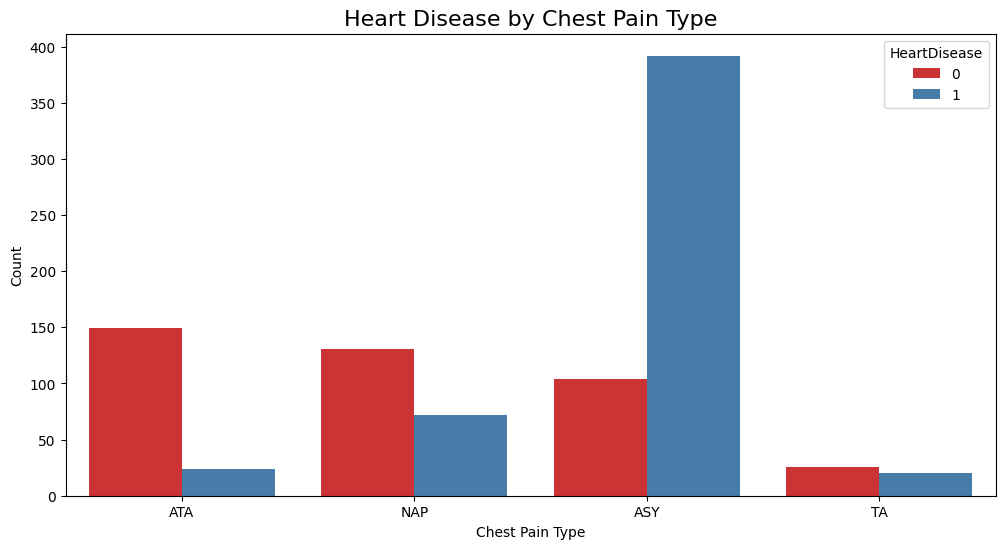

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ChestPainType', hue='HeartDisease', data=heart_data_csv, palette='Set1')
plt.title('Heart Disease by Chest Pain Type', fontsize=16)
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.show()

## 🫀 What is the relationship between age and max heart rate?

### (r6) Use the scatterplot to highlight correlation

A scatterplot was used to highlight the correlation between between the patients' ages and the maximum heart rate recorded.

#### 6) Insight: Older Patients had lower maximum heart rates recorded.

<ipython-input-11-bb3b6c5c9c42>:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Age', y='MaxHR', data=heart_data_csv, palette='Set1')


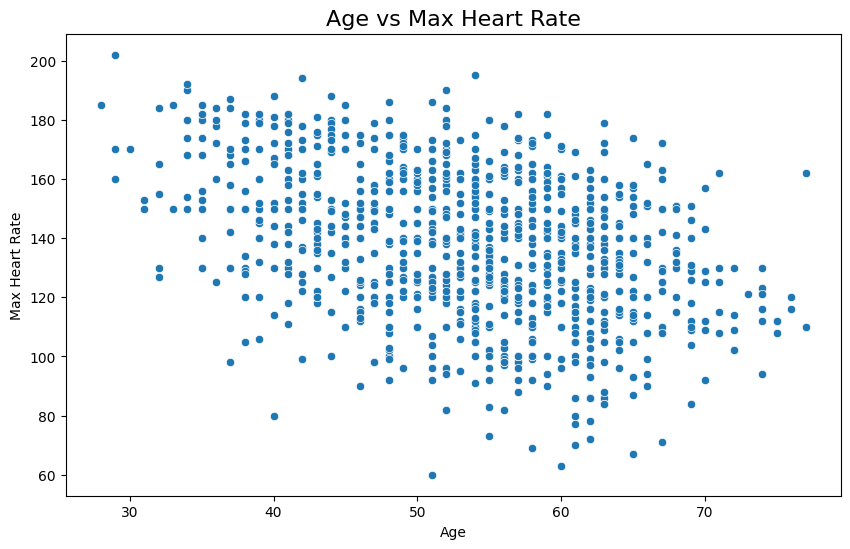

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MaxHR', data=heart_data_csv, palette='Set1')
plt.title('Age vs Max Heart Rate', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()

## 🫀 How does max heart rate and age affect diagnosis of heart disease?

### (r6) Use the scatterplot to highlight correlation

Conducting a similar analysis to insight #6, now by adjusting the hue of the scatter plot we can tell the effect of age and maximum heart rate on a heart disease diagnosis.

#### 7) Insight: Older patients with lower maximum heart rate recorded have a higher chance of having heart disease.

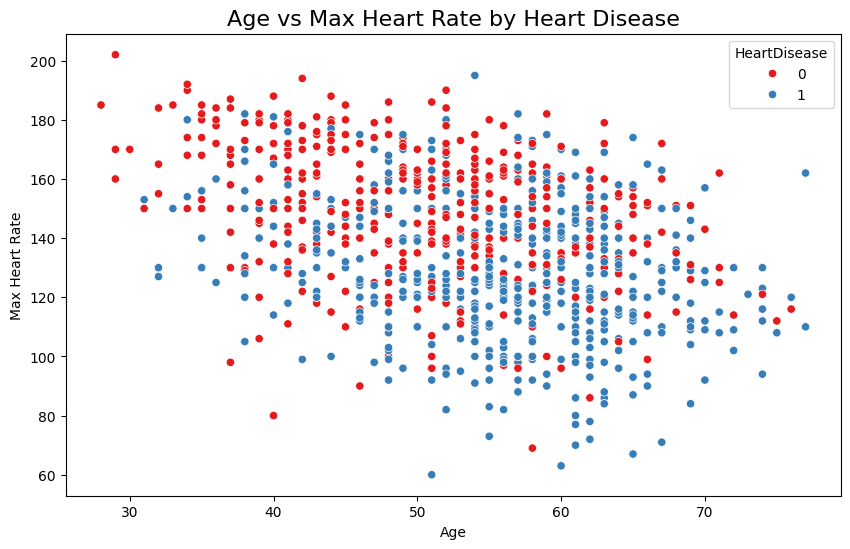

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MaxHR', data=heart_data_csv, hue='HeartDisease', palette='Set1')
plt.title('Age vs Max Heart Rate by Heart Disease', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()

## 🫀 How does age contribute to having types of chest pain?

### (r7) Split the data by certain categories to explore the numerical distributions

The column ChestPainType was separated into categories to visualize the numerical distribution of the Age column.

#### 8) Insight: Tachycardia-induced Angina (TA) chest pain affected the widest range of patients, although most were close to 60. Asymptotic chest pain (ASY) targeted smallest segment of patients, while atypical chest pain (ATA) targeted the youngest patients out of all the different chest pain types in the dataset.

<ipython-input-13-64cbcf704431>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ChestPainType', y='Age', data=heart_data_csv, palette='Reds')


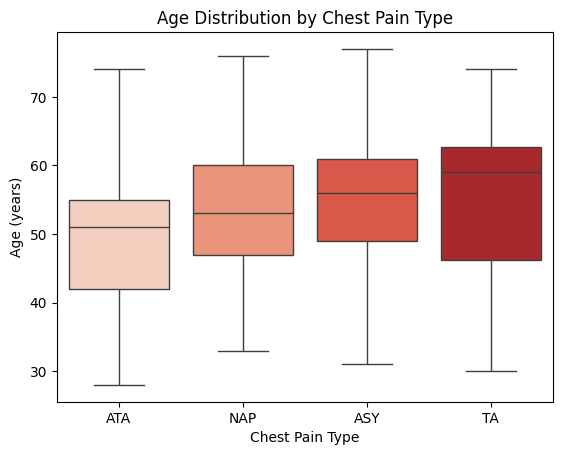

In [ ]:
# Boxplot of Age by ChestPainType
sns.boxplot(x='ChestPainType', y='Age', data=heart_data_csv, palette='Reds')
plt.title('Age Distribution by Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Age (years)')
plt.show()



## 🫀 How does cholesterol contribute to heart disease diagnosis?

#### 9) Insight: Having very low cholesterol (almost 0) makes it very likely that a patient has heart disease, due to the high frequency.

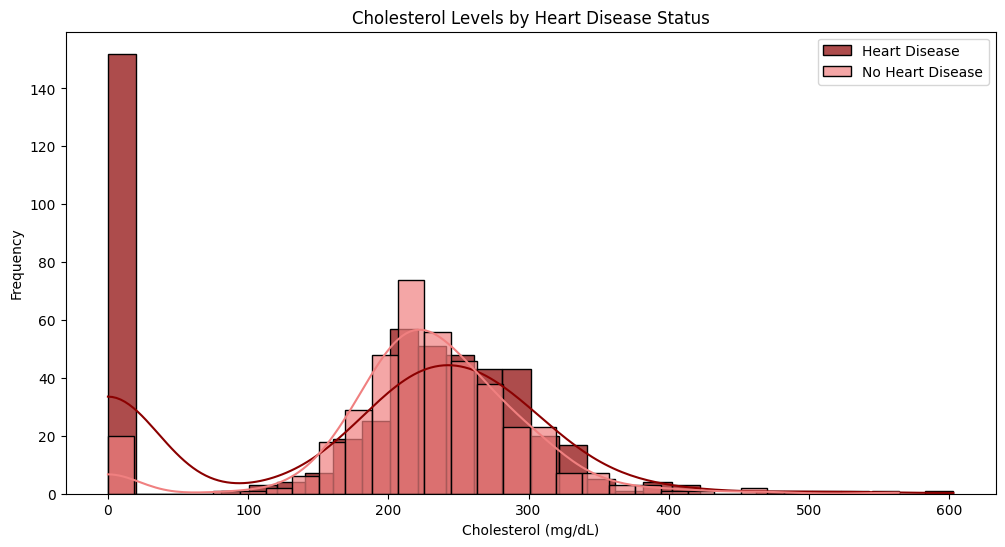

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(heart_data_csv[heart_data_csv['HeartDisease'] == 1]['Cholesterol'], bins=30, kde=True, color='darkred', label='Heart Disease', alpha=0.7)
sns.histplot(heart_data_csv[heart_data_csv['HeartDisease'] == 0]['Cholesterol'], bins=30, kde=True, color='lightcoral', label='No Heart Disease', alpha=0.7)
plt.title('Cholesterol Levels by Heart Disease Status')
plt.xlabel('Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

## 🫀 How does exercise engina relate to heart disease?

#### 10) More patients with exercise angina also reported heart disease, making eercise angina a strong predictor of heart disease.  

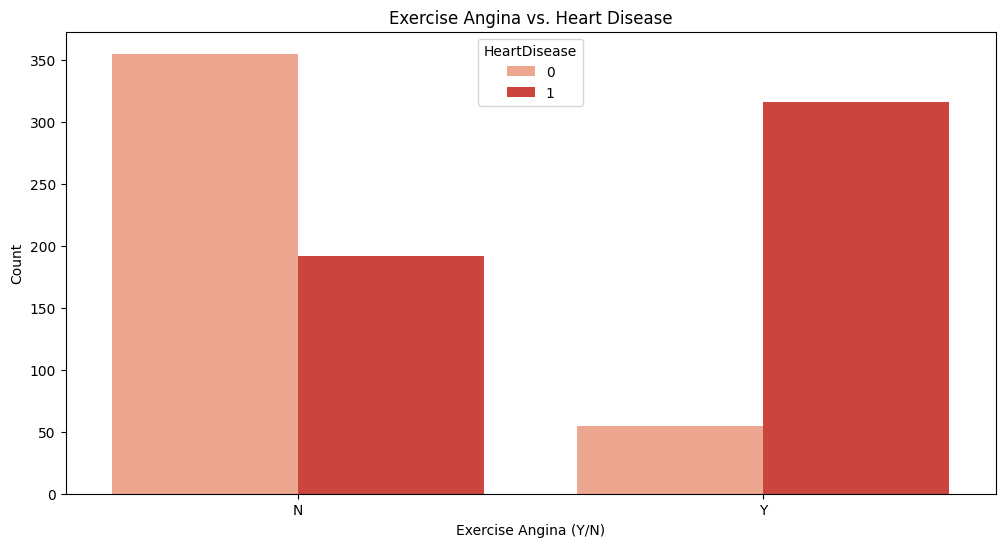

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(x='ExerciseAngina', hue='HeartDisease', data=heart_data_csv, palette='Reds', dodge=True)
plt.title('Exercise Angina vs. Heart Disease')
plt.xlabel('Exercise Angina (Y/N)')
plt.ylabel('Count')
plt.show()

# 🫀 Conclusion

In conclusion of the exploratory data analysis of the Heart Failure dataset, the following insights were gathered with various techniques:

1) Insight: The age group most commonly represented among the patients (whether they had heart disease or not) was between 50 and 60 years old.

2) Insight: The most prevalent type of chest pain among the patients in dataset is atypical chest pain.

3) Insight: Overall male patients were more represented in the types of chest pain, with greatest discrepancy between male and female patients occuring with atypical chest pain.

4) Insight: While male patients are represented more in the dataset, they also have higher proportinality/chance of having heart disease compared to female patients. So, heart disease is found far more often in male patients.

5) Insight: Atypical chest pain contributes most to the eventual diagnosis of heart disease compared to the other types of chest pain.

6) Insight: Older Patients had lower maximum heart rates recorded.

7) Insight: Older patients with lower maximum heart rate recorded have a higher chance of having heart disease.

8) Insight: Tachycardia-induced Angina (TA) chest pain affected the widest range of patients, although most were close to 60. Asymptotic chest pain (ASY) targeted smallest segment of patients, while atypical chest pain (ATA) targeted the youngest patients out of all the different chest pain types in the dataset.

9) Insight: Having very low cholesterol (almost 0) makes it very likely that a patient has heart disease, due to the high frequency. '

10) More patients with exercise angina also reported heart disease, making eercise angina a strong predictor of heart disease.  
